# Datasets & DataLoaders

Код для обработки образцов данных может стать грязным и трудным для поддержания; мы в идеале хотим, чтобы наш код набора данных был отделеным от нашего модельного учебного кода для лучшей читабельности и модульности. PyTorch предоставляет два примитивных данных: torch.utils.data.DataLoader и torch.utils.data.Dataset, которые позволяют использовать предварительно загруженные наборы данных, а также ваши собственные данные. Dataset хранит образцы и соответствующие им этикетки, и DataLoader обертывает детерабельный вокруг Dataset чтобы обеспечить легкий доступ к образцам.

Библиотеки доменов PyTorch предоставляют ряд предварительно загруженных наборов данных (таких как FashionMNIST), которые Подкласс torch.utils.data.Dataset и реализовывать функции, специфичные для конкретных данных. Они могут быть использованы для прототипа и сравниваем вашу модель. 

## Загрузка набора данных 

Вот пример того, как загрузить набор данных Fashion-MNIST из TorchVision. Fashion-MNIST - это набор данных из изображений статей Zalando. Каждый пример содержит изображение серого цвета и связанную с ним метку из одного из классов.

Мы загружаем набор данных FashionMNIST со следующими параметрами:
- root - Это путь, по которому хранятся данные тренировки/теста,
- train - определяет набор данных для обучения или тестирования,
- download=True - загрузить данные из Интернета, если они недоступны в root.
- transform и target_transform - указать функцию и преобразования метки



In [4]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import v2
import matplotlib.pyplot as plt


training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

## Итеризация и визуализация набора данных 

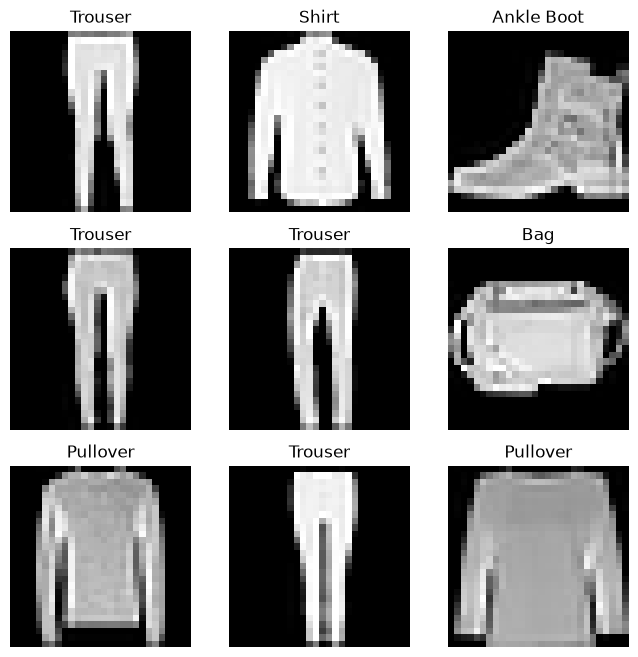

In [5]:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

## Создание пользовательского набора данных

Пользовательский класс Dataset должен выполнять три функции: `__init__`, `__len__`, и `__gettiem__`.

In [6]:
import os
import pandas as pd
from torchvision.io import decode_image

class CustomImageDataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
        self.img_labels = pd.read_csv(annotations_file)
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
        image = decode_image(img_path)
        label = self.img_labels.iloc[idx, 1]
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image, label

## Подготовка данных для обучения с DataLoaders 

In [7]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)

## Итерации через DataLoader

Мы загрузили этот набор данных в DataLoader и можем итерировать через набор данных по мере необходимости. Каждая итерация ниже возвращает партию train_features и train_labels (содержит batch_size=64 признаки и метки соответственно). Потому что мы указали shuffle=True, после того, как мы итерируем по всем партиям, данные перетасовываются.

Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


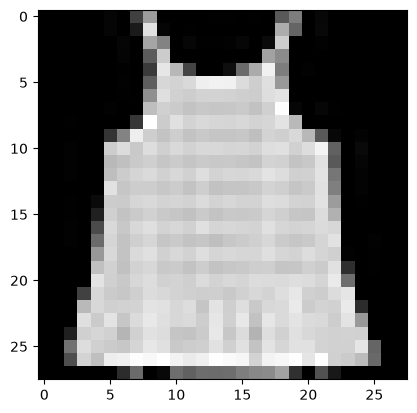

Label: 0


In [8]:
# Display image and label.
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img, cmap="gray")
plt.show()
print(f"Label: {label}")